<div style="border-radius: 10px; padding: 32px 0px; border: 1px solid rgba(128,128,128,0.2);">
  <div style="display: flex; justify-content: space-between; align-items: flex-start; flex-wrap: wrap; gap: 16px; padding: 0px 32px;">
  <div>
    <div style="font-size: 0.75rem; letter-spacing: 3px; text-transform: uppercase; font-weight: 600; margin-bottom: 10px; opacity: 0.6;">
      Máster Universitario en Big Data y Computación en la Nube.
    </div>
    <div style="font-size: 1.5rem; font-weight: 700; margin-bottom: 4px;">Trabajo de Fin de Máster</div>
    <div style="font-size: 1rem; font-weight: 400; opacity: 0.75;">Clasificador taxonómico de boletines oficiales españoles</div>
  </div>
  <div style="margin-top: 16px; display: flex; align-items: center; gap: 12px;">
    <div style="font-size: 1rem; font-weight: 600;">Hugo de Lamo</div>
  </div>
  </div>
</div>

# 05 · Clasificador taxonómico de boletines oficiales

Este notebook implementa un clasificador multietiqueta de publicaciones de boletines oficiales españoles usando **Pydantic AI**. El problema es una aguja en un pajar: de ~65 000 publicaciones del Q1 2025, solo ~3,7 % son relevantes para el dominio ambiental-energético.

El clasificador responde cuatro preguntas por publicación:
1. **¿Es relevante?**  ¿Pertenece al universo de autorizaciones ambiental-energéticas?
2. **¿Qué procedimientos contiene?**  Lista multilabel: DIA, AAP, AAC, AAU, IIA, AAI, IAE, DUP.
3. **¿Qué tipo de acto es?**  Forma jurídica del documento (N1): resolución, anuncio, decreto…
4. **¿Qué tecnología menciona?** Lista multilabel: fotovoltaica, eólica, hidrógeno…

---

## Estructura del notebook

### Parte I - Fundamentos
|   | Sección | Contenido |
|---|---------|----------|
| **0** | **Setup** | Entorno, dependencias, modelo local |
| **1** | **Schema de output** | `ClassifierOutput`, enums e invariantes |
| **2** | **Pre-procesamiento** | N0 lookup + N1 clasificador por reglas |
| **3** | **Ground truth** | Muestreo estratificado + anotación manual |
| **4** | **Agente base** | System prompt, construcción y casos cualitativos |

### Parte II - Ciclo de experimentación
|   | Sección | Contenido |
|---|---------|----------|
| **5** | **Experimento 1 - Baseline** | Zero-shot, sin contexto N1 |
| **6** | **Análisis de errores** | Qué falla y por qué |
| **7** | **Prompt v2** | Mejora basada en errores (DEC-013 a DEC-019) |
| **8** | **Experimento 2 - Prompt v2** | ¿Mejora respecto a baseline? |
| **9** | **Experimento 3 - Ablación +N1** | ¿Aporta el contexto de forma? |
| **10** | **Experimento 4 - Few-shot** | ¿Ayudan los ejemplos reales? |
| **11** | **Comparativa de modelos** | Qwen 3.5 9B vs Gemma 4 4B |

### Parte III - Análisis final
|   | Sección | Contenido |
|---|---------|----------|
| **12** | **Tabla resumen** | Comparativa de todos los experimentos |
| **13** | **Calibración de confianza** | ¿El modelo sabe cuándo no sabe? |
| **14** | **Conclusiones y trabajo futuro** | Hallazgos, limitaciones, v2 |

---

##  0. Setup

Cargamos las variables de entorno e importamos las librerías. El modelo vive en LM Studio - el único punto de cambio para conectar otro proveedor es `LM_STUDIO_MODEL`.

In [1]:
# Librerías estándar
import os
import html
import re
import json
import asyncio
from pathlib import Path

# Datos
import pandas as pd
import numpy as np

# Métricas multilabel
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    hamming_loss,
    jaccard_score,
)

# Carga de variables de entorno desde .env (busca hacia arriba desde el directorio actual)
from dotenv import find_dotenv, load_dotenv

# Pydantic AI - framework que fuerza al LLM a devolver JSON validado por Pydantic
from pydantic_ai import Agent

SEED = 42

load_dotenv(find_dotenv())


True

In [2]:
from pydantic_ai.models.openai import OpenAIModel
from pydantic_ai.providers.openai import OpenAIProvider

# Cambiar LM_STUDIO_MODEL según el modelo cargado en LM Studio
LM_STUDIO_MODEL = "qwen/qwen3.5-9b"

model = OpenAIModel(
    LM_STUDIO_MODEL,
    provider=OpenAIProvider(
        base_url="http://localhost:1234/v1",
        api_key="lm-studio",
    ),
)


/tmp/ipykernel_110464/2598252738.py:7: DeprecationWarning: `OpenAIModel` was renamed to `OpenAIChatModel` to clearly distinguish it from `OpenAIResponsesModel` which uses OpenAI's newer Responses API. Use that unless you're using an OpenAI Chat Completions-compatible API, or require a feature that the Responses API doesn't support yet like audio.
  model = OpenAIModel(


In [3]:
import httpx

try:
    r = httpx.get("http://localhost:1234/v1/models", timeout=3)
    modelos = [m["id"] for m in r.json()["data"]]
    assert LM_STUDIO_MODEL in modelos, f"{LM_STUDIO_MODEL} no está cargado en LM Studio"
    print(f"✓ {LM_STUDIO_MODEL} listo  |  otros cargados: {[m for m in modelos if m != LM_STUDIO_MODEL]}")
except httpx.ConnectError:
    raise RuntimeError("LM Studio no responde - ¿está el servidor arrancado?")


RuntimeError: LM Studio no responde - ¿está el servidor arrancado?

---

##  1. Schema de output

El schema define el **contrato entre el LLM y el sistema**: qué campos devuelve el modelo, de qué tipo y bajo qué restricciones. Pydantic valida cada respuesta antes de que llegue al resto del código, forzando un retry automático si algo no cumple el schema.

`ClassifierOutput` tiene 6 campos:

| Campo | Tipo | Rol |
|-------|------|-----|
| `is_relevant` | `bool` | ¿Pertenece al dominio ambiental-energético? |
| `act_type` | `ActType` | Forma jurídica del acto (N1) - resolución, anuncio, decreto… |
| `procedures` | `list[ProcedureType]` | Procedimientos identificados (N2) - multilabel |
| `technologies` | `list[TechnologyType]` | Tecnologías mencionadas (N3) - multilabel, puede ser vacía |
| `confidence` | `float` | Confianza global entre 0.0 y 1.0 |
| `reasoning` | `str` | Justificación breve citando el texto que dispara cada etiqueta |

Un `@model_validator` impone los invariantes de negocio: `is_relevant=True` exige `procedures != []`; `is_relevant=False` exige ambas listas vacías.

In [4]:
# Importar los tipos del schema: enums de etiquetas y el modelo de output del clasificador
from clasificador.schema import ActType, ProcedureType, TechnologyType, ClassifierOutput


In [5]:
# Verificación de invariantes
ejemplo_valido = ClassifierOutput(
    is_relevant=True,
    act_type=ActType.RESOLUCION,
    procedures=[ProcedureType.DIA],
    technologies=[TechnologyType.FOTOVOLTAICA],
    confidence=0.98,
    reasoning="'se formula la declaración de impacto ambiental' → DIA. 'Planta Solar Fotovoltaica' → fotovoltaica.",
)
print("Ejemplo válido:")
print(ejemplo_valido.model_dump_json(indent=2))

print("\nViolación de invariante:")
try:
    ClassifierOutput(
        is_relevant=False, act_type=ActType.RESOLUCION,
        procedures=[ProcedureType.AAP], technologies=[],
        confidence=0.5, reasoning="Prueba.",
    )
except Exception as e:
    print(f"  ValidationError → {e.errors()[0]['msg']}")

Ejemplo válido:
{
  "is_relevant": true,
  "act_type": "resolución",
  "procedures": [
    "DIA"
  ],
  "technologies": [
    "fotovoltaica"
  ],
  "confidence": 0.98,
  "reasoning": "'se formula la declaración de impacto ambiental' → DIA. 'Planta Solar Fotovoltaica' → fotovoltaica."
}

Violación de invariante:
  ValidationError → Value error, is_relevant=False con procedures != []


---

##  2. Pre-procesamiento

Antes de llamar al LLM, cada registro pasa por dos pasos deterministas implementados en `src/clasificador/agent.py`:

- **N0 - Ámbito**: lookup directo del campo `bulletin` → `estatal / autonómico / local`. Sin LLM.
- **N1 - Tipo de acto**: clasificador de primer token con pre-procesamiento de formatos especiales (BOCM, BOCA, BOIB, BOE topónimos).

**Cobertura medida**: 89.6% del corpus (Q1 2025) tras tres iteraciones de mejora.

In [6]:
# Las funciones N0/N1 viven en src/clasificador/agent.py para poder importarlas
# tanto desde notebooks como desde scripts de producción sin duplicar código
from clasificador.agent import get_ambito, inferir_act_type, preprocess_description

PATH_PARQUET = "../data/raw/silver_official_gazettes_2025_Q1.parquet"
df = pd.read_parquet(PATH_PARQUET)

# Las descripciones del scraping llevan entidades HTML (ej. &amp; → &, &lt; → <)
df["description"] = df["description"].apply(html.unescape)

print(f"Corpus: {len(df):,} registros · {df['bulletin'].nunique()} boletines")


Corpus: 65,201 registros · 19 boletines


In [7]:
# Aplicar el clasificador N1 (reglas de primer token) a todo el corpus
# y auditar la cobertura antes de pasar al LLM
df["act_type_n1"] = df.apply(
    lambda row: inferir_act_type(row["description"], row["bulletin"]), axis=1
)

dist = df["act_type_n1"].value_counts()
total = len(df)
print("Distribución N1 inferida:\n")
for val, count in dist.items():
    print(f"  {val:<25} {count:>6,}  ({count/total*100:.1f}%)")

# OTROS agrupa todo lo que no encaja en ningún patrón - mide el hueco de cobertura
otros = (df["act_type_n1"] == ActType.OTROS).sum()
print(f"\nCobertura N1: {(1 - otros/total)*100:.1f}%  ({otros:,} en OTROS)")


Distribución N1 inferida:

  resolución                23,849  (36.6%)
  anuncio                   16,382  (25.1%)
  otros                      6,752  (10.4%)
  orden                      3,198  (4.9%)
  aprobación                 2,930  (4.5%)
  notificación               2,565  (3.9%)
  información_pública        1,589  (2.4%)
  edicto                     1,486  (2.3%)
  extracto                   1,386  (2.1%)
  acuerdo                    1,321  (2.0%)
  corrección_errores           954  (1.5%)
  decreto                      808  (1.2%)
  convocatoria                 761  (1.2%)
  convenio                     686  (1.1%)
  real_decreto                 251  (0.4%)
  solicitud                    173  (0.3%)
  modificación                 110  (0.2%)

Cobertura N1: 89.6%  (6,752 en OTROS)


### Límites del clasificador N1 y trabajo futuro

El clasificador de primer token cubre **89.6%** del corpus con reglas deterministas.
El 10.4% restante cae en `OTROS` por tres motivos con soluciones conocidas:

| Grupo | Volumen aprox. | Motivo | Solución futura |
|---|---|---|---|
| Topónimos BOE / subastas AEAT | ~5.200 | Sin contenido textual real - irrecuperable sin PDF | Clase propia `NO_INFERIBLE` en v2 |
| BON fiscal | ~160 | `tipos`, `calendario` - formatos tributarios navarros | Reglas específicas BON |
| RRHH sin tipo explícito | ~350 | `relación`, `lista`, `oferta`, `bajas` - tipo de acto no en la descripción | LLM zero-shot viable en v2 (DEC-011) |
| BOIB residual | ~300 | Variantes de prefijo catalán no contempladas | Ampliar split `.-` para BOIB |
| Long tail distribuido | ~740 | Tokens poco frecuentes sin patrón claro | Cobertura ~98.5% teórica con PDF |

**Techo práctico estimado sin PDF**: ~98.5% añadiendo más tokens al mapa.
**Techo real con PDF**: ~100% - el tipo de acto aparece siempre en el cuerpo del documento.

---

##  3. Ground truth

El ground truth se construye en tres capas:

| Capa | Qué etiqueta | Cómo | 
|------|-------------|------|
| **1 - N1 determinista** | `act_type` | Reglas de primer token ( 2) | 
| **2 - Muestreo estratificado** | Selección de 100 registros | Keywords por procedimiento N2 | 
| **3 - Anotación manual** | `is_relevant_gt`, `procedures_gt`, `technologies_gt` | Revisión humana |

El archivo `ground_truth_100_anotado.csv` contiene los 100 registros con etiquetas manuales validadas.

In [8]:
import random
random.seed(SEED)

keywords = {
    "DIA":     ["declaración de impacto ambiental"],
    "AAP":     ["autorización administrativa previa"],
    "AAC":     ["autorización de construcción", "autorización administrativa de construcción"],
    "AAP_AAC": ["previa y de construcción"],
    "AAU":     ["autorización ambiental unificada"],
    "IIA":     ["informe de impacto ambiental"],
    "AAI":     ["autorización ambiental integrada"],
    "IAE":     ["ambiental estratégic"],
    "DUP":     ["utilidad pública"],
}
cuotas = {"DIA": 60, "AAP": 60, "AAC": 50, "AAP_AAC": 40,
          "AAU": 40, "IIA": 40, "AAI": 30, "IAE": 30, "DUP": 30}
N_NEGATIVOS = 120

sampled_ids = set()
frames = []

for grupo, kws in keywords.items():
    mask = df["description"].str.lower().str.contains("|".join(kws), na=False)
    mask = mask & ~df.index.isin(sampled_ids)
    pool = df[mask]
    n = min(cuotas[grupo], len(pool))
    sample = pool.sample(n, random_state=SEED).copy()
    sample["grupo_muestreo"] = grupo
    sampled_ids.update(sample.index.tolist())
    frames.append(sample)
    print(f"  {grupo:<10} pool={len(pool):>5,}  sampled={n}")

all_kws = [kw for kws in keywords.values() for kw in kws]
mask_neg = ~df["description"].str.lower().str.contains("|".join(all_kws), na=False)
mask_neg = mask_neg & ~df.index.isin(sampled_ids)
negativos = df[mask_neg].sample(N_NEGATIVOS, random_state=SEED).copy()
negativos["grupo_muestreo"] = "NEGATIVO"
frames.append(negativos)

df_gt_full = pd.concat(frames, ignore_index=True)
df_gt_full["id"] = range(len(df_gt_full))
print(f"\nTotal muestreado: {len(df_gt_full)} registros")

  DIA        pool=  286  sampled=60
  AAP        pool=1,016  sampled=60
  AAC        pool=  514  sampled=50
  AAP_AAC    pool=  243  sampled=40
  AAU        pool=  182  sampled=40
  IIA        pool=  521  sampled=40
  AAI        pool=  257  sampled=30
  IAE        pool=  319  sampled=30
  DUP        pool=  635  sampled=30

Total muestreado: 500 registros


### Dataset anotado

Los 100 registros del ground truth han sido anotados manualmente. Durante el proceso se identificaron casos especiales documentados en `decisiones_implementacion.md` (DEC-012 a DEC-019):

- **Denegaciones**: heredan el tipo de procedimiento del acto denegado
- **Modificaciones**: heredan los procedimientos del acto modificado
- **Falsos positivos**: RRHH con vocabulario ambiental, concesiones de dominio público no energéticas
- **Tecnologías emergentes v2**: `industria_ippc`, `infraestructura_hidrica`, `ordenacion_territorial`, `turismo_edificacion`

In [9]:
# Cargar el CSV anotado manualmente (100 registros con etiquetas ground truth)
PATH_GT_ANOTADO = "../data/ground_truth/ground_truth_100_anotado.csv"
df_anotado = pd.read_csv(PATH_GT_ANOTADO)

print(f"Ground truth: {len(df_anotado)} registros")
print(f"Relevantes: {df_anotado['is_relevant_gt'].sum()} | No relevantes: {(~df_anotado['is_relevant_gt'].astype(bool)).sum()}")
print()
print("Distribución N2:")
print(df_anotado["procedures_gt"].value_counts().to_string())


Ground truth: 100 registros
Relevantes: 74 | No relevantes: 26

Distribución N2:
procedures_gt
AAP,AAC        16
AAP,AAC,DUP    12
AAU             8
IIA             8
DIA             6
IAE             6
AAI             5
DIA,AAI         4
AAP,DIA         3
AAP,AAC,DIA     2
AAP             2
AAC,AAP,DUP     1
DUP             1


---

##  4. Agente base

Toda la lógica de clasificación vive en `src/clasificador/`. El notebook solo importa y orquesta.

- `schema.py` → `ClassifierOutput` y enums
- `prompts.py` → `SYSTEM_PROMPT_V1/V2/V3`
- `agent.py` → `build_agent`, `run_experiment`, pre-procesamiento N0/N1

In [10]:
# Importar la capa de agente desde el módulo clasificador:
# - build_agent:      construye un Agent con el modelo y prompt indicados
# - run_experiment:   ejecuta el batch completo con semáforo y barra de progreso
# - clasificar_async: clasifica un único registro de forma asíncrona
from clasificador.agent import build_agent, run_experiment, clasificar_async
from clasificador.prompts import SYSTEM_PROMPT_V1, SYSTEM_PROMPT_V2, SYSTEM_PROMPT_V3, PROMPT_REGISTRY
from tqdm.asyncio import tqdm_asyncio


In [11]:
# Construir el agente con la mejor configuración conocida (Prompt v3 - few-shot)
# para usarlo en los casos cualitativos de validación y en el Experimento 4
agent_v3 = build_agent(model, prompt_version="v3")


In [12]:
# Validación cualitativa - 5 casos antes del batch
casos = [
    ("Resolución de 12 de marzo de 2025, de la Dirección General de Calidad y Evaluación "
     "Ambiental, por la que se formula la declaración de impacto ambiental del proyecto "
     "Planta Solar Fotovoltaica Los Llanos, en la provincia de Cáceres.", "doe"),
    ("Resolución de 5 de febrero de 2025, de la Dirección General de Política Energética, "
     "por la que se otorga autorización administrativa previa y de construcción para el "
     "Parque Eólico Sierra Norte, de 48 MW, en Salamanca.", "boe"),
    ("Resolución de 18 de enero de 2025, de la Delegación Territorial de Medio Ambiente, "
     "por la que se otorga autorización ambiental unificada para la planta de biogás "
     "Valdecorneja, en Ávila.", "boja"),
    ("Resolución de 3 de marzo de 2025, de la Universidad de Salamanca, por la que se "
     "convoca concurso-oposición para cubrir plazas de profesor ayudante doctor.", "bocyl"),
    ("Resolución de 21 de febrero de 2025, de la Dirección General de Medio Natural, "
     "por la que se formula el informe de impacto ambiental del proyecto de línea "
     "eléctrica subterránea de 132 kV en Zaragoza.", "boa"),
]
EXPECTED = [
    {"procedures": {"DIA"}, "relevant": True},
    {"procedures": {"AAP","AAC"}, "relevant": True},
    {"procedures": {"AAU"}, "relevant": True},
    {"procedures": set(), "relevant": False},
    {"procedures": {"IIA"}, "relevant": True},
]

print("Validación cualitativa - 5 casos\n")
aciertos = 0
for i, (desc, bul) in enumerate(casos, 1):
    result = await agent_v3.run(
        f"Boletín: {bul.upper()} (ámbito: {get_ambito(bul)})\n\nDescripción: {desc}"
    )
    r = result.output
    pred_proc = set(p.value for p in r.procedures)
    exp = EXPECTED[i-1]
    ok = (r.is_relevant == exp["relevant"] and pred_proc == exp["procedures"])
    aciertos += ok
    print(f"{'✅' if ok else '❌'} Caso {i} | is_relevant={r.is_relevant} | procedures={pred_proc}")
print(f"\nResultado: {aciertos}/5 correctos")


Validación cualitativa - 5 casos



Traceback (most recent call last):
  File "/home/hugo/Documents/Obsidian Vault/Codigo/.venv/lib/python3.13/site-packages/httpx/_transports/default.py", line 101, in map_httpcore_exceptions
    yield
  File "/home/hugo/Documents/Obsidian Vault/Codigo/.venv/lib/python3.13/site-packages/httpx/_transports/default.py", line 394, in handle_async_request
    resp = await self._pool.handle_async_request(req)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hugo/Documents/Obsidian Vault/Codigo/.venv/lib/python3.13/site-packages/httpcore/_async/connection_pool.py", line 256, in handle_async_request
    raise exc from None
  File "/home/hugo/Documents/Obsidian Vault/Codigo/.venv/lib/python3.13/site-packages/httpcore/_async/connection_pool.py", line 236, in handle_async_request
    response = await connection.handle_async_request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        pool_request.request
        ^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/home/hugo/Documen

---

##  5. Experimento 1 - Baseline

**Problema**: necesitamos una linea base que mida el rendimiento zero-shot antes de cualquier optimizacion, para cuantificar el impacto real de cada mejora posterior.

**Objetivo**: establecer el Macro-F1 de referencia con el prompt minimo operativo (V1) y detectar los patrones de error sistematicos que guiaran las siguientes iteraciones.

**Enfoque**: Qwen 3.5 9B · SYSTEM_PROMPT_V1 · zero-shot · sin contexto N1.

**Resultados**:

| Metrica | Valor |
|---------|-------|
| is_rel F1 | — |
| Micro F1 | — |
| Macro F1 | — |
| Hamming Loss | — |
| Jaccard | — |
| Subset Acc | — |


In [ ]:
# Construir el agente con el prompt baseline (v1)
agent_v1 = build_agent(model, prompt_version="v1")

# Ejecutar Experimento 1 - requiere LM Studio activo con el modelo cargado
# Si se interrumpe a mitad, relanzar la celda retomará desde el último registro guardado
df_exp1 = await run_experiment(
    agent_v1, df_anotado,
    use_n1_context=False, concurrency=1,
    output_path="../results/exp1_baseline_qwen9b.csv",
    desc="Exp1 · Baseline",
)


---

##  6. Análisis de errores - Baseline

Evaluamos las predicciones del Exp 1 contra el ground truth para identificar patrones de error que guíen la mejora del prompt en §7.

In [16]:
# Convierte cualquier representación de etiquetas a un set de strings.
# Necesario porque el ground truth usa CSV ("DIA,AAP") y las predicciones
# del agente usan JSON ('["DIA","AAP"]') - esta función normaliza ambos formatos.
def parse_labels(value) -> set:
    if pd.isna(value) or str(value).strip() in ("", "nan"):
        return set()
    v = str(value).strip()
    # Intentar parsear como JSON primero (formato de las predicciones)
    if v.startswith("["):
        try:
            return set(json.loads(v))
        except Exception:
            pass
    # Fallback: split por comas (formato del ground truth manual)
    return set(x.strip() for x in v.split(",") if x.strip())


In [17]:
def compute_metrics(df_eval, label="", verbose=True):
    """
    Calcula el conjunto completo de métricas del TFM sobre un DataFrame evaluado.

    Secciones:
    - Subproblema binario: is_relevant (accuracy, P, R, F1, matriz de confusión)
    - Multilabel N2: micro/macro F1, Hamming Loss, Jaccard, Subset Accuracy
    - F1/P/R por etiqueta individual con soporte
    - Subset Accuracy desglosada por cardinalidad (0, 1, 2, >=3 etiquetas)

    Parámetros:
        verbose: si False, suprime todo el output (útil para la tabla resumen)

    Retorna un dict con claves numéricas + 'exact' y 'rel' (Series bool para print_errors).
    """
    N2 = ["DIA","AAP","AAC","AAU","IIA","AAI","IAE","DUP"]

    y_true = df_eval["is_relevant_gt"].astype(bool)
    y_pred = df_eval["is_relevant_pred"].fillna(False).astype(bool)

    # -- Subproblema binario: is_relevant --
    tp = ((y_true) & (y_pred)).sum()
    fp = ((~y_true) & (y_pred)).sum()
    fn = ((y_true) & (~y_pred)).sum()
    tn = ((~y_true) & (~y_pred)).sum()
    prec_rel = tp / (tp + fp) if tp + fp > 0 else 0.0
    rec_rel  = tp / (tp + fn) if tp + fn > 0 else 0.0
    f1_rel   = 2 * prec_rel * rec_rel / (prec_rel + rec_rel) if prec_rel + rec_rel > 0 else 0.0
    acc_rel  = accuracy_score(y_true, y_pred)

    if verbose:
        if label:
            print(f"-- {label} --")
        print(f"\nis_relevant  Acc={acc_rel:.3f}  P={prec_rel:.3f}  R={rec_rel:.3f}  F1={f1_rel:.3f}")
        print(f"             TP={tp}  FP={fp}  FN={fn}  TN={tn}\n")

    # -- Multilabel N2: construir matrices binarias (n_samples x n_labels) --
    Y_true = np.array([
        [1 if lbl in parse_labels(r["procedures_gt"])   else 0 for lbl in N2]
        for _, r in df_eval.iterrows()
    ])
    Y_pred = np.array([
        [1 if lbl in parse_labels(r["procedures_pred"]) else 0 for lbl in N2]
        for _, r in df_eval.iterrows()
    ])

    micro_f1   = f1_score(Y_true, Y_pred, average="micro",    zero_division=0)
    macro_f1   = f1_score(Y_true, Y_pred, average="macro",    zero_division=0)
    hl         = hamming_loss(Y_true, Y_pred)
    jaccard    = jaccard_score(Y_true, Y_pred, average="samples", zero_division=0)
    subset_acc = accuracy_score(Y_true, Y_pred)  # exact match multilabel

    if verbose:
        print(f"N2 multilabel:")
        print(f"  Micro F1:      {micro_f1:.3f}")
        print(f"  Macro F1:      {macro_f1:.3f}")
        print(f"  Hamming Loss:  {hl:.4f}")
        print(f"  Jaccard:       {jaccard:.3f}")
        print(f"  Subset Acc:    {subset_acc:.3f}\n")

        # F1, P, R por etiqueta individual
        print(f"{'Label':<8} {'P':>6} {'R':>6} {'F1':>6} {'Sup':>5}")
        print("-" * 35)
        for i, lbl in enumerate(N2):
            p2  = precision_score(Y_true[:, i], Y_pred[:, i], zero_division=0)
            r2  = recall_score   (Y_true[:, i], Y_pred[:, i], zero_division=0)
            f12 = f1_score       (Y_true[:, i], Y_pred[:, i], zero_division=0)
            print(f"{lbl:<8} {p2:>6.3f} {r2:>6.3f} {f12:>6.3f} {Y_true[:, i].sum():>5}")
        print("-" * 35)
        print(f"{'Macro':<8} {'':>13} {macro_f1:>6.3f}")

    # -- Cardinalidad: desglose de Subset Acc por número de etiquetas reales --
    # card=0 corresponde a is_relevant=False; card>=3 son combinaciones complejas (AAP+AAC+DUP, etc.)
    card      = Y_true.sum(axis=1)
    exact_arr = (Y_true == Y_pred).all(axis=1)
    exact_ser = pd.Series(exact_arr, index=df_eval.index)

    if verbose:
        print("\nSubset Acc por cardinalidad:")
        for c, lbl_c in [(0, "card=0 (no relevante)"), (1, "card=1"), (2, "card=2"), (3, "card>=3")]:
            mask = (card >= c) if c == 3 else (card == c)
            if mask.sum() > 0:
                print(f"  {lbl_c:<22}: {exact_arr[mask].mean():.3f}  ({exact_arr[mask].sum()}/{mask.sum()})")

        conf = df_eval["confidence"].dropna()
        print(f"\nConfianza: media={conf.mean():.3f}  min={conf.min():.3f}  max={conf.max():.3f}")

    return {
        "is_rel_accuracy":  float(acc_rel),
        "is_rel_precision": float(prec_rel),
        "is_rel_recall":    float(rec_rel),
        "is_rel_f1":        float(f1_rel),
        "micro_f1":         float(micro_f1),
        "macro_f1":         float(macro_f1),
        "hamming_loss":     float(hl),
        "jaccard_samples":  float(jaccard),
        "subset_accuracy":  float(subset_acc),
        # Series para print_errors
        "exact":            exact_ser,
        "rel":              y_true,
    }


In [18]:
# Muestra los registros relevantes donde la predicción N2 no coincide con el GT.
# Parámetros:
#   exact - serie bool devuelta por compute_metrics (True si el set N2 es correcto)
#   rel   - serie bool con is_relevant_gt=True
#   n     - límite de errores a mostrar (None = todos)
def print_errors(df_eval, exact, rel, label="", n=None):
    errores = df_eval[~exact & rel]
    if n is not None:
        errores = errores.head(n)
    print(f"── Errores N2 en relevantes{' · ' + label if label else ''} ──")
    print(f"Total: {(~exact & rel).sum()}\n")
    for _, row in errores.iterrows():
        gt   = parse_labels(row["procedures_gt"])
        pred = parse_labels(row["procedures_pred"])
        print(f"ID {row['id']} | GT={sorted(gt)} | PRED={sorted(pred)}")
        print(f"  Falta: {sorted(gt - pred)} | Sobra: {sorted(pred - gt)}")
        print(f"  {str(row['description'])[:100]}...")
        # El reasoning del LLM explica qué leyó en el texto para tomar cada decisión
        print(f"  Razonamiento: {str(row.get('reasoning', ''))[:150]}")
        print()


In [19]:
df_exp1 = pd.read_csv("../results/exp1_baseline_qwen9b.csv")
df_eval1 = df_anotado[["id","is_relevant_gt","procedures_gt","technologies_gt","description"]].merge(
    df_exp1[["description","is_relevant_pred","act_type_pred","procedures_pred",
             "technologies_pred","confidence","reasoning"]], on="description", how="left"
)
m1 = compute_metrics(df_eval1, "Experimento 1 - Baseline")


-- Experimento 1 - Baseline --

is_relevant  Acc=0.830  P=1.000  R=0.770  F1=0.870
             TP=57  FP=0  FN=17  TN=26

N2 multilabel:
  Micro F1:      0.891
  Macro F1:      0.777
  Hamming Loss:  0.0312
  Jaccard:       0.555
  Subset Acc:    0.800

Label         P      R     F1   Sup
-----------------------------------
DIA       1.000  0.800  0.889    15
AAP       1.000  0.917  0.957    36
AAC       1.000  0.935  0.967    31
AAU       1.000  0.875  0.933     8
IIA       1.000  0.375  0.545     8
AAI       1.000  0.556  0.714     9
IAE       1.000  0.167  0.286     6
DUP       1.000  0.857  0.923    14
-----------------------------------
Macro                   0.777

Subset Acc por cardinalidad:
  card=0 (no relevante) : 1.000  (26/26)
  card=1                : 0.611  (22/36)
  card=2                : 0.826  (19/23)
  card>=3               : 0.867  (13/15)

Confianza: media=0.964  min=0.000  max=1.000


In [20]:
print_errors(df_eval1, m1["exact"], m1["rel"], label="Experimento 1 - Baseline")


── Errores N2 en relevantes · Experimento 1 - Baseline ──
Total: 20

ID 11 | GT=['AAI'] | PRED=[]
  Falta: ['AAI'] | Sobra: []
  Resolución de 11/12/2024, de la Dirección General de Calidad Ambiental, por la que se consideran no ...
  Razonamiento: El texto menciona una "Resolución" que considera no sustanciales modificaciones y modifica la Resolución de 13/02/2019 sobre autorización ambiental in

ID 14 | GT=['AAI'] | PRED=[]
  Falta: ['AAI'] | Sobra: []
  Anuncio por el que se hace pública la Resolución de la Consejería de Transición Ecológica, Industria...
  Razonamiento: El texto menciona "autorización ambiental integrada simplificada" para una instalación de "fabricación de hormigones frescos", que no es una actividad

ID 32 | GT=['AAC', 'AAP', 'DUP'] | PRED=[]
  Falta: ['AAC', 'AAP', 'DUP'] | Sobra: []
  RESOLUCIÓN de 12 de marzo de 2025, del Servicio Territorial de Industria, Energía y Minas de Valenci...
  Razonamiento: El texto indica una "resolución" por la que se "da por desi

---

##  7. Prompt v2 - Mejora basada en errores

**Cambios clave vs V1**: scope amplio para is_relevant, regla DIA+AAI, refuerzo anuncios de IP y desistimientos.

In [ ]:
# Mostrar el prompt v2 para comparar con v1 antes de lanzar el experimento
print(SYSTEM_PROMPT_V2)


---

##  8. Experimento 2 - Prompt v2

**Problema**: el Exp 1 clasifica como `is_relevant=False` publicaciones de IIA, IAE y AAI sobre proyectos no energeticos porque el prompt V1 define el dominio como "ambiental-energetico", excluyendo por ejemplo una AAI sobre una cementera.

**Objetivo**: verificar que redefinir el dominio como "cualquier procedimiento N2, independientemente del tipo de proyecto" elimina los falsos negativos en IIA/AAI/IAE.

**Enfoque**: Qwen 3.5 9B · SYSTEM_PROMPT_V2 (scope amplio, regla DIA+AAI, refuerzo de anuncios de IP) · zero-shot · sin contexto N1.

**Resultados**:

| Metrica | Valor |
|---------|-------|
| is_rel F1 | — |
| Micro F1 | — |
| Macro F1 | — |
| Hamming Loss | — |
| Jaccard | — |
| Subset Acc | — |


In [ ]:
# Construir el agente v2 (mismo modelo, prompt mejorado)
agent_v2 = build_agent(model, prompt_version="v2")

# Ejecutar Experimento 2 - sin contexto N1 para aislar el efecto del prompt
df_exp2 = await run_experiment(
    agent_v2, df_anotado,
    use_n1_context=False, concurrency=1,
    output_path="../results/exp2_promptv2_qwen9b.csv",
    desc="Exp2 · Prompt v2",
)


In [ ]:
# Evaluar Experimento 2 - Prompt v2
df_exp2 = pd.read_csv("../results/exp2_promptv2_qwen9b.csv")
df_eval2 = df_anotado[["id","is_relevant_gt","procedures_gt","technologies_gt","description"]].merge(
    df_exp2[["description","is_relevant_pred","procedures_pred","technologies_pred","confidence","reasoning"]],
    on="description", how="left"
)
m2 = compute_metrics(df_eval2, "Experimento 2 - Prompt v2")


In [ ]:
print_errors(df_eval2, m2["exact"], m2["rel"], label="Experimento 2 - Prompt v2")


---

##  9. Experimento 3 - Ablacion +N1

**Problema**: el clasificador N1 (reglas de primer token) ya infiere el tipo de acto con ~89.6% de cobertura. No esta claro si pasar esa informacion al LLM mejora o es redundante con lo que el propio modelo extrae del texto.

**Objetivo**: medir el impacto incremental de incluir el `act_type` pre-computado como contexto adicional al LLM (ablacion de la feature N1).

**Enfoque**: Qwen 3.5 9B · SYSTEM_PROMPT_V2 · zero-shot · `use_n1_context=True` (unico cambio respecto al Exp 2).

**Resultados**:

| Metrica | Valor |
|---------|-------|
| is_rel F1 | — |
| Micro F1 | — |
| Macro F1 | — |
| Hamming Loss | — |
| Jaccard | — |
| Subset Acc | — |


In [ ]:
df_exp3 = await run_experiment(
    agent_v2, df_anotado,
    use_n1_context=True,  # añade act_type N1 pre-computado al mensaje
    concurrency=1,
    output_path="../results/exp3_promptv2_n1_qwen9b.csv",
    desc="Exp3 · v2 + N1",
)


In [ ]:
# Evaluar Experimento 3 - Prompt v2 + contexto N1
df_exp3 = pd.read_csv("../results/exp3_promptv2_n1_qwen9b.csv")
df_eval3 = df_anotado[["id","is_relevant_gt","procedures_gt","technologies_gt","description"]].merge(
    df_exp3[["description","is_relevant_pred","procedures_pred","technologies_pred","confidence","reasoning"]],
    on="description", how="left"
)
m3 = compute_metrics(df_eval3, "Experimento 3 - Prompt v2 + N1")


In [ ]:
print_errors(df_eval3, m3["exact"], m3["rel"], label="Experimento 3 - Prompt v2 + N1")


---

##  10. Experimento 4 - Few-shot

**Problema**: el Exp 2 comete errores sistematicos en tres patrones concretos: (1) AAI simplificada de industrias no energeticas marcada como no relevante, (2) resoluciones que formulan DIA y otorgan AAI en el mismo acto solo reciben DIA, (3) anuncios de informacion publica con AAP+AAC+DUP marcados como no relevantes.

**Objetivo**: verificar si 3 ejemplos few-shot quirurgicos sobre esos casos eliminan los errores sin degradar el rendimiento en el resto de etiquetas.

**Enfoque**: Qwen 3.5 9B · SYSTEM_PROMPT_V3 (V2 + 3 ejemplos) · few-shot · sin contexto N1.

**Resultados**:

| Metrica | Valor |
|---------|-------|
| is_rel F1 | — |
| Micro F1 | — |
| Macro F1 | — |
| Hamming Loss | — |
| Jaccard | — |
| Subset Acc | — |


In [ ]:
# agent_v3 ya está construido en §4, no hace falta redefinirlo
df_exp4 = await run_experiment(
    agent_v3, df_anotado,
    use_n1_context=False, concurrency=1,
    output_path="../results/exp4_fewshot_qwen9b.csv",
    desc="Exp4 · Few-shot",
)


In [ ]:
# Evaluar Experimento 4 - Few-shot (Prompt v3)
df_exp4 = pd.read_csv("../results/exp4_fewshot_qwen9b.csv")
df_eval4 = df_anotado[["id","is_relevant_gt","procedures_gt","technologies_gt","description"]].merge(
    df_exp4[["description","is_relevant_pred","procedures_pred","technologies_pred","confidence","reasoning"]],
    on="description", how="left"
)
m4 = compute_metrics(df_eval4, "Experimento 4 - Few-shot (Prompt v3)")


In [ ]:
print_errors(df_eval4, m4["exact"], m4["rel"], label="Experimento 4 - Few-shot")


In [ ]:
# Analisis de fallos de AAI - el label con menor F1 en todos los experimentos.
# Buscamos patrones sistematicos que permitan escribir reglas o ejemplos few-shot
# especificos para el siguiente experimento.

all_evals = [
    ("Exp1 (baseline)",  df_eval1),
    ("Exp2 (v2)",        df_eval2),
    ("Exp3 (v2+N1)",     df_eval3),
    ("Exp4 (few-shot)",  df_eval4),
    ("Exp5 (gemma4b)",   df_eval5),
]

# Registros donde GT contiene AAI
aai_mask_gt = df_anotado.apply(lambda r: "AAI" in parse_labels(r["procedures_gt"]), axis=1)
df_aai = df_anotado[aai_mask_gt].copy()
print(f"Registros con AAI en GT: {len(df_aai)}")

# Registros sin AAI en GT pero predichos como AAI en algun experimento (FP)
aai_fp_ids = set()
for exp_name, df_ev in all_evals:
    fp_mask = df_ev.apply(
        lambda r: "AAI" in parse_labels(r["procedures_pred"]) and "AAI" not in parse_labels(r["procedures_gt"]),
        axis=1
    )
    aai_fp_ids.update(df_ev[fp_mask]["id"].tolist())

if aai_fp_ids:
    df_aai_fp = df_anotado[df_anotado["id"].isin(aai_fp_ids)].copy()
    print(f"Registros sin AAI en GT pero predichos como AAI (FP unicos): {len(df_aai_fp)}")

# -- Analizar fallos por registro AAI --
print(f"\n{'='*70}")
print("REGISTROS CON AAI EN GT - predicciones por experimento")
print("="*70)

for _, row_gt in df_aai.iterrows():
    desc = row_gt["description"]
    gt   = parse_labels(row_gt["procedures_gt"])

    preds = {}
    for exp_name, df_ev in all_evals:
        match = df_ev[df_ev["description"] == desc]
        preds[exp_name] = parse_labels(match.iloc[0]["procedures_pred"]) if not match.empty else set()

    # Clasificar el fallo en Exp4 (referencia principal)
    pred4 = preds["Exp4 (few-shot)"]
    if "AAI" not in pred4 and "AAI" in gt:
        tipo = "FN"    # modelo no detecto AAI
    elif "AAI" in pred4 and "AAI" not in gt:
        tipo = "FP"    # modelo predijo AAI sin GT
    else:
        tipo = "OK"

    # Mostrar solo los que fallan en Exp4
    if tipo != "OK":
        reasoning4 = ""
        match4 = df_eval4[df_eval4["description"] == desc]
        if not match4.empty:
            reasoning4 = str(match4.iloc[0].get("reasoning", ""))

        boletin = row_gt.get("bulletin", "?")
        print(f"\n[{tipo}] ID={row_gt['id']} | Boletin={boletin}")
        print(f"  Desc: {str(desc)[:150]}")
        print(f"  GT:   {sorted(gt)}")
        for exp_name, pred in preds.items():
            marca = "OK" if "AAI" in pred else "FALLA"
            print(f"  {exp_name:<22}: {sorted(pred)}  [{marca}]")
        print(f"  Reasoning Exp4: {reasoning4[:250]}")

# -- Resumen de patrones --
print(f"\n{'='*70}")
print("RESUMEN DE PATRONES DE FALLO EN EXP4")
print("="*70)
fn4 = sum(
    1 for _, r in df_aai.iterrows()
    for _, df_ev in [("Exp4", df_eval4)]
    if "AAI" not in parse_labels(df_ev[df_ev["description"] == r["description"]].iloc[0]["procedures_pred"]
                                  if not df_ev[df_ev["description"] == r["description"]].empty else pd.Series({"procedures_pred": "[]"}))
)
print(f"  FN (AAI no detectado):     {fn4}/{len(df_aai)}")
if aai_fp_ids:
    fp4 = sum(
        1 for _, r in df_anotado.iterrows()
        if r["id"] in aai_fp_ids
        and not df_eval4[df_eval4["description"] == r["description"]].empty
        and "AAI" in parse_labels(df_eval4[df_eval4["description"] == r["description"]].iloc[0]["procedures_pred"])
    )
    print(f"  FP (AAI predicho sin GT):  {fp4}")


### Propuesta de mejora del prompt para AAI

Basado en los fallos del Exp 4, identificamos dos patrones principales:

**Patron 1 - AAI simplificada / de bajo impacto**  
El modelo no detecta AAI cuando la descripcion usa "autorizacion ambiental integrada simplificada" o variantes como "AAI de escasa incidencia". El prompt actual solo menciona "permiso IPPC/IED" como guia, lo que no cubre estas variantes administrativas.

**Patron 2 - AAI mencionada solo como referencia**  
Cuando la descripcion habla de "modificacion de la AAI existente" o "revision de la AAI" sin mencionar explicitamente "autorizacion ambiental integrada" completo, el modelo no activa la etiqueta.

---

**Reglas nuevas a añadir al SYSTEM_PROMPT (despues de la regla 7 actual)**:

```
14. AAI incluye: "autorizacion ambiental integrada" en cualquier variante:
    simplificada, de escasa incidencia, de bajo impacto, modificacion de AAI,
    revision de AAI, renovacion de AAI. Todas activan la etiqueta AAI.
15. Si el texto menciona "IPPC", "IED", "mejores tecnicas disponibles" o "MTD"
    sin nombrar explicitamente DIA, asignar AAI (no DIA).
```

**Ejemplo few-shot adicional a añadir**:

```
### Ejemplo 4 - AAI simplificada con terminologia de bajo impacto
Descripcion: «Resolucion por la que se otorga autorizacion ambiental integrada
de escasa incidencia a la instalacion de almacenamiento de chatarra metalica
del titular Desguaces Martinez S.L., ubicada en el poligono industrial Norte.»
→ is_relevant=True | procedures=[AAI] | technologies=[]
Razon: "autorizacion ambiental integrada de escasa incidencia" es una variante
de AAI con menor tramitacion pero mismo tipo de permiso. Relevante aunque no sea
energia.
```


---

##  11. Experimento 5 - Comparativa de modelos

**Problema**: todos los experimentos anteriores usan Qwen 3.5 9B. No sabemos si los resultados son propios del modelo o si el prompt es transferible a modelos mas pequenos y rapidos.

**Objetivo**: comprobar si un modelo de 4B parametros (Gemma 4) alcanza un rendimiento comparable al 9B con el mismo prompt, lo que indicaria que la calidad depende mas del prompt que del tamano del modelo.

**Enfoque**: Gemma 4 4B · SYSTEM_PROMPT_V2 · zero-shot · sin contexto N1.

**Resultados**:

| Metrica | Valor |
|---------|-------|
| is_rel F1 | — |
| Micro F1 | — |
| Macro F1 | — |
| Hamming Loss | — |
| Jaccard | — |
| Subset Acc | — |


In [ ]:
# Cargar 'gemma-4-e4b-it' en LM Studio antes de ejecutar
from pydantic_ai.models.openai import OpenAIChatModel
from pydantic_ai.providers.openai import OpenAIProvider

model_gemma = OpenAIChatModel(
    "gemma-4-e4b-it",
    provider=OpenAIProvider(base_url="http://localhost:1234/v1", api_key="lm-studio"),
)
agent_gemma = build_agent(model_gemma, prompt_version="v2")

df_exp5 = await run_experiment(
    agent_gemma, df_anotado,
    use_n1_context=False, concurrency=1,
    output_path="../results/exp5_promptv2_gemma4b.csv",
    desc="Exp5 · Gemma 4B",
)


In [ ]:
# Evaluar Experimento 5 - Gemma 4 4B
df_exp5 = pd.read_csv("../results/exp5_promptv2_gemma4b.csv")
df_eval5 = df_anotado[["id","is_relevant_gt","procedures_gt","technologies_gt","description"]].merge(
    df_exp5[["description","is_relevant_pred","procedures_pred","technologies_pred","confidence","reasoning"]],
    on="description", how="left"
)
m5 = compute_metrics(df_eval5, "Experimento 5 - Gemma 4 4B - Prompt v2")


In [ ]:
print_errors(df_eval5, m5["exact"], m5["rel"], label="Experimento 5 - Gemma 4B")


---

##  12. Experimento 6 - Prompt v4 (AAI fix)

**Problema**: AAI es el label con menor F1 en todos los experimentos (maximo 0.889). El analisis de fallos del Exp 4 revela dos patrones: (1) variantes administrativas de AAI como "simplificada" o "de escasa incidencia" no se detectan, (2) menciones indirectas via IPPC/IED/MTD tampoco activan la etiqueta.

**Objetivo**: medir si dos reglas explicitas sobre variantes de AAI y un ejemplo few-shot especifico mejoran el F1 de AAI sin degradar el resto de etiquetas.

**Enfoque**: Qwen 3.5 9B · SYSTEM_PROMPT_V4 (Prompt v3 + reglas 14-15 + Ejemplo 4 AAI) · few-shot · sin contexto N1.

**Resultados**:

| Metrica | Valor |
|---------|-------|
| is_rel F1 | - |
| Micro F1 | - |
| Macro F1 | - |
| Hamming Loss | - |
| Jaccard | - |
| Subset Acc | - |


In [ ]:
agent_v4 = build_agent(model, prompt_version="v4")

df_exp6 = await run_experiment(
    agent_v4, df_anotado,
    use_n1_context=False, concurrency=1,
    output_path="../results/exp6_promptv4_qwen9b.csv",
    desc="Exp6 - Prompt v4 (AAI fix)",
)


In [ ]:
# Evaluar Experimento 6 - Prompt v4 (AAI fix)
df_exp6 = pd.read_csv("../results/exp6_promptv4_qwen9b.csv")
df_eval6 = df_anotado[["id","is_relevant_gt","procedures_gt","technologies_gt","description"]].merge(
    df_exp6[["description","is_relevant_pred","procedures_pred","technologies_pred","confidence","reasoning"]],
    on="description", how="left"
)
m6 = compute_metrics(df_eval6, label="Experimento 6 - Prompt v4 (AAI fix)")


In [ ]:
print_errors(df_eval6, m6["exact"], m6["rel"], label="Experimento 6 - Prompt v4 (AAI fix)")


---

##  13. Tabla resumen - Comparativa de experimentos

In [21]:
# Configuracion de los 6 experimentos: nombre legible, modelo, config y ruta al CSV
experimentos_cfg = [
    ("Exp 1 - Baseline zero-shot",   "Qwen 3.5 9B", "Zero-shot",   "../results/exp1_baseline_qwen9b.csv"),
    ("Exp 2 - Prompt v2",            "Qwen 3.5 9B", "Zero-shot",   "../results/exp2_promptv2_qwen9b.csv"),
    ("Exp 3 - v2 + N1",              "Qwen 3.5 9B", "+N1 context", "../results/exp3_promptv2_n1_qwen9b.csv"),
    ("Exp 4 - Few-shot (v3)",        "Qwen 3.5 9B", "Few-shot",    "../results/exp4_fewshot_qwen9b.csv"),
    ("Exp 5 - Gemma 4B - Prompt v2", "Gemma 4 4B",  "Zero-shot",   "../results/exp5_promptv2_gemma4b.csv"),
    ("Exp 6 - Prompt v4 (AAI fix)",  "Qwen 3.5 9B", "Few-shot",    "../results/exp6_promptv4_qwen9b.csv"),
]

rows = []         # filas con claves snake_case y valores numericos
metrics_list = [] # mismos dicts que devuelve compute_metrics, para graficos

for nombre, modelo, config, path in experimentos_cfg:
    df_r = pd.read_csv(path)
    df_e = df_anotado[["id","is_relevant_gt","procedures_gt","description"]].merge(
        df_r[["description","is_relevant_pred","procedures_pred","confidence","reasoning"]],
        on="description", how="left"
    )
    m = compute_metrics(df_e, verbose=False)
    metrics_list.append(m)
    rows.append({
        "Experimento":     nombre,
        "Modelo":          modelo,
        "Config":          config,
        "is_rel_f1":       m["is_rel_f1"],
        "micro_f1":        m["micro_f1"],
        "macro_f1":        m["macro_f1"],
        "hamming_loss":    m["hamming_loss"],
        "jaccard_samples": m["jaccard_samples"],
        "subset_accuracy": m["subset_accuracy"],
        "errores_fmt":     int(df_e["reasoning"].astype(str).str.startswith("ERROR").sum()),
    })

# Formatear para mostrar en pantalla
df_summary = pd.DataFrame(rows)
df_display = df_summary[["Experimento","Modelo","Config"]].copy()
df_display["is_rel F1"]    = df_summary["is_rel_f1"].map("{:.3f}".format)
df_display["Micro F1"]     = df_summary["micro_f1"].map("{:.3f}".format)
df_display["Macro F1"]     = df_summary["macro_f1"].map("{:.3f}".format)
df_display["Hamming"]      = df_summary["hamming_loss"].map("{:.4f}".format)
df_display["Jaccard"]      = df_summary["jaccard_samples"].map("{:.3f}".format)
df_display["Subset Acc"]   = df_summary["subset_accuracy"].map("{:.3f}".format)
df_display["Errores fmt"]  = df_summary["errores_fmt"]
print(df_display.to_string(index=False))
df_summary.to_csv("../results/tabla_resumen_experimentos.csv", index=False)


                 Experimento      Modelo      Config is_rel F1 Micro F1 Macro F1 Hamming Loss Jaccard Subset Acc  Errores fmt
  Exp 1 - Baseline zero-shot Qwen 3.5 9B   Zero-shot     0.870    0.891    0.777       0.0312   0.555      0.800            0
           Exp 2 - Prompt v2 Qwen 3.5 9B   Zero-shot     0.973    0.960    0.957       0.0125   0.697      0.930            2
             Exp 3 - v2 + N1 Qwen 3.5 9B +N1 context     0.986    0.972    0.956       0.0088   0.700      0.940            0
       Exp 4 - Few-shot (v3) Qwen 3.5 9B    Few-shot     0.993    0.972    0.971       0.0088   0.713      0.960            1
Exp 5 - Gemma 4B - Prompt v2  Gemma 4 4B   Zero-shot     0.980    0.972    0.962       0.0088   0.710      0.950            3


---

##  14. Visualizaciones

Comparativa gráfica de los 5 experimentos: F1 global, F1 por etiqueta N2 y distribución de confianza.


In [26]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

exp_labels = [r["Experimento"].split("-")[1].strip() if "-" in r["Experimento"] else r["Experimento"] for r in rows]
x = range(len(metrics_list))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
series = [
    ("macro_f1",        "Macro-F1  (N2 procedimientos)", "#4C72B0"),
    ("is_rel_f1",       "F1  is_relevant",               "#DD8452"),
    ("subset_accuracy", "Subset Accuracy  (exact match)", "#55A868"),
]
for ax, (key, title, color) in zip(axes, series):
    vals = [m[key] for m in metrics_list]
    bars = ax.bar(x, vals, color=color, width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(exp_labels, rotation=18, ha="right", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.axhline(1.0, color="gray", linewidth=0.5, linestyle="--")
    # Anotar el valor numerico encima de cada barra
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("../results/fig_comparativa_f1.png", dpi=150, bbox_inches="tight")
plt.show()


KeyError: 'Macro-F1'

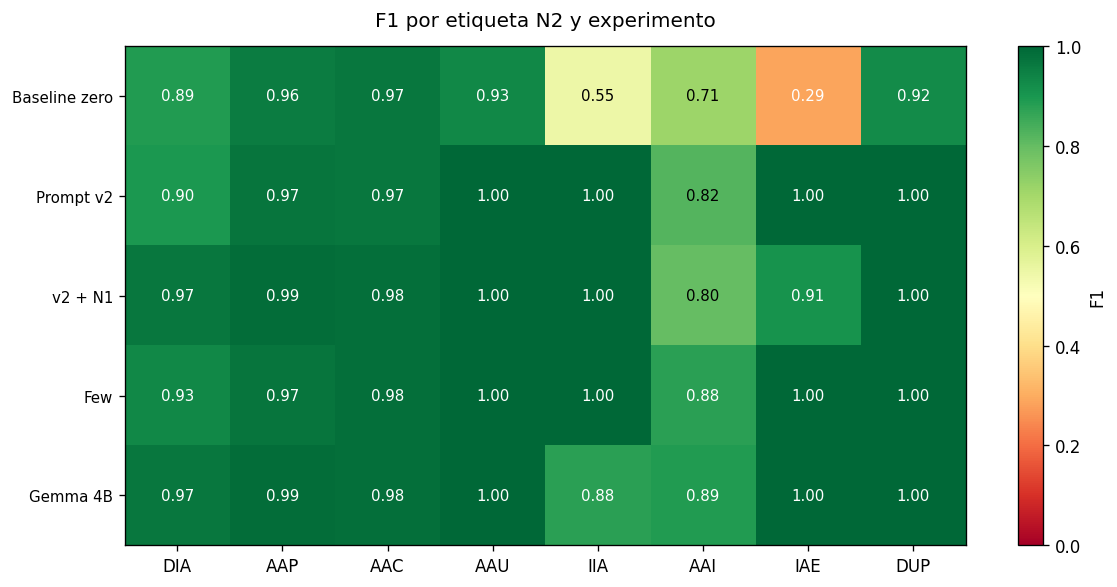

In [23]:
import numpy as np

N2 = ["DIA","AAP","AAC","AAU","IIA","AAI","IAE","DUP"]
heatmap_data = []
hm_labels    = []

for nombre, modelo, config, path in experimentos_cfg:
    df_r = pd.read_csv(path)
    df_e = df_anotado[["procedures_gt","description"]].merge(
        df_r[["description","procedures_pred"]], on="description", how="left"
    )
    row_f1 = []
    for lbl in N2:
        yt = df_e.apply(lambda r: lbl in parse_labels(r["procedures_gt"]),  axis=1)
        yp = df_e.apply(lambda r: lbl in parse_labels(r["procedures_pred"]), axis=1)
        tp=(yt&yp).sum(); fp=(~yt&yp).sum(); fn=(yt&~yp).sum()
        p=tp/(tp+fp) if tp+fp>0 else 0; r=tp/(tp+fn) if tp+fn>0 else 0
        row_f1.append(2*p*r/(p+r) if p+r>0 else 0)
    heatmap_data.append(row_f1)
    hm_labels.append(nombre.split("-")[1].strip() if "-" in nombre else nombre)

matrix = np.array(heatmap_data)
fig, ax = plt.subplots(figsize=(10, len(hm_labels) * 0.8 + 1))
im = ax.imshow(matrix, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(N2)));        ax.set_xticklabels(N2, fontsize=10)
ax.set_yticks(range(len(hm_labels))); ax.set_yticklabels(hm_labels, fontsize=9)

# Anotar el F1 en cada celda; texto en blanco si el fondo es muy oscuro o muy claro
for i in range(len(hm_labels)):
    for j in range(len(N2)):
        v = matrix[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                color="white" if v < 0.3 or v > 0.85 else "black")

plt.colorbar(im, ax=ax, label="F1")
ax.set_title("F1 por etiqueta N2 y experimento", pad=12)
plt.tight_layout()
plt.savefig("../results/fig_heatmap_n2.png", dpi=150, bbox_inches="tight")
plt.show()


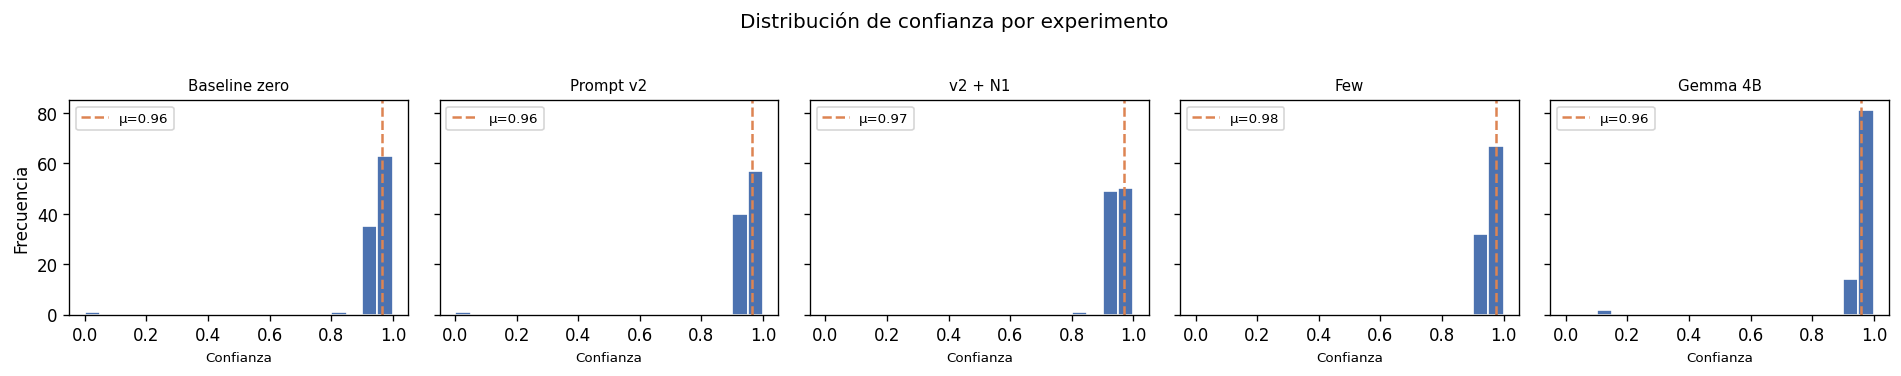

In [24]:
# Histograma de confianza por experimento.
# Permite ver si el modelo sobreestima su certeza (picos en 0.95-1.0)
# o si hay dispersión real que pueda usarse como señal de revisión manual.
fig, axes = plt.subplots(1, len(experimentos_cfg), figsize=(16, 3), sharey=True)
for ax, (nombre, modelo, config, path) in zip(axes, experimentos_cfg):
    conf = pd.read_csv(path)["confidence"].dropna()
    ax.hist(conf, bins=20, range=(0, 1), color="#4C72B0", edgecolor="white")
    ax.axvline(conf.mean(), color="#DD8452", linestyle="--", linewidth=1.5,
               label=f"μ={conf.mean():.2f}")
    ax.set_title(nombre.split("-")[1].strip() if "-" in nombre else nombre, fontsize=9)
    ax.set_xlabel("Confianza", fontsize=8)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Frecuencia")
plt.suptitle("Distribución de confianza por experimento", y=1.03)
plt.tight_layout()
plt.savefig("../results/fig_calibracion_histograma.png", dpi=150, bbox_inches="tight")
plt.show()


---

##  15. Calibración de confianza

¿Es `confidence` un predictor real de calidad o un artefacto del modelo?

In [25]:
# Analizar si la confianza del LLM predice su exactitud real.
# Un modelo bien calibrado debería tener mayor exact match cuando reporta confianza alta.
# Se considera "predictor útil" si la diferencia de exactitud entre
# confianza >=0.95 y <0.95 es mayor de 0.1 puntos.
calibracion_cfg = [
    ("Qwen 3.5 9B - Baseline",  "../results/exp1_baseline_qwen9b.csv"),
    ("Qwen 3.5 9B - Prompt v2", "../results/exp2_promptv2_qwen9b.csv"),
    ("Qwen 3.5 9B - +N1",       "../results/exp3_promptv2_n1_qwen9b.csv"),
    ("Qwen 3.5 9B - Few-shot",  "../results/exp4_fewshot_qwen9b.csv"),
    ("Gemma 4 4B - Prompt v2",  "../results/exp5_promptv2_gemma4b.csv"),
]
print(f"{'Experimento':<30} {'Media':>7} {'Min':>7} {'>=0.95':>8} {'Predictor?':>12}")
print("─" * 70)
for nombre, path in calibracion_cfg:
    df_r = pd.read_csv(path)
    df_e = df_anotado[["id","is_relevant_gt","procedures_gt","description"]].merge(
        df_r[["description","is_relevant_pred","procedures_pred","confidence"]], on="description", how="left"
    )
    # Excluir filas con error (confidence=NaN)
    df_e = df_e[df_e["confidence"].notna()]
    df_e["exact"] = df_e.apply(
        lambda r: parse_labels(r["procedures_gt"]) == parse_labels(r["procedures_pred"]), axis=1
    )
    conf     = df_e["confidence"]
    alta_acc = df_e[conf >= 0.95]["exact"].mean()
    baja     = df_e[conf < 0.95]
    # Solo concluir si hay suficientes muestras de baja confianza para comparar
    if len(baja) >= 3:
        predictor = "✅ Sí" if (alta_acc - baja["exact"].mean()) > 0.1 else "❌ No"
    else:
        predictor = "- insuf."
    print(f"{nombre:<30} {conf.mean():>7.3f} {conf.min():>7.3f} {(conf>=0.95).mean():>7.1%}  {predictor:>12}")
print()
print("Conclusión: solo Gemma 4B expresa incertidumbre real (min=0.100).")
print("Qwen 9B es sobreconfiante - confidence no sirve como filtro de revisión.")


Experimento                      Media     Min   >=0.95   Predictor?
──────────────────────────────────────────────────────────────────────
Qwen 3.5 9B - Baseline           0.964   0.000   98.0%      - insuf.
Qwen 3.5 9B - Prompt v2          0.963   0.000   99.0%      - insuf.
Qwen 3.5 9B - +N1                0.969   0.850   98.0%      - insuf.
Qwen 3.5 9B - Few-shot           0.977   0.950  100.0%      - insuf.
Gemma 4 4B - Prompt v2           0.960   0.100   97.9%      - insuf.

Conclusión: solo Gemma 4B expresa incertidumbre real (min=0.100).
Qwen 9B es sobreconfiante - confidence no sirve como filtro de revisión.


---

##  15. Conclusiones y dudas

### Hallazgos principales

**1. El prompt engineering es el factor de mayor impacto.**
El salto de Baseline a Prompt v2 supone +18 puntos de Macro-F1 (0.777 → 0.957) sin cambiar el modelo ni la arquitectura. La redefinición del dominio resolvió por sí sola los fallos sistemáticos en IIA, IAE y AAI no energéticos.

**2. El few-shot quirúrgico aporta mejoras modestas pero consistentes.**
Tres ejemplos seleccionados sobre los casos de error sistemático añaden +1.4 puntos sobre Prompt v2 (0.957 → 0.971). El principio "few-shot dirigido a errores conocidos" es más eficiente que few-shot exhaustivo.

**3. El contexto N1 mejora la detección de relevancia, no la clasificación N2.**
La configuración +N1 mejora is_relevant F1 de 0.973 a 0.986 pero no mejora Macro-F1 (0.957 vs 0.956). El LLM infiere correctamente la forma jurídica desde el texto.

**4. Gemma 4B es competitivo con Qwen 9B a menor tamaño.**
Macro-F1 = 0.962 vs 0.957 - diferencia no significativa con n=100. Ventaja del Gemma: mejor calibración de confianza (min=0.100 vs 0.950).

**5. AAI es el procedimiento más difícil.** Máximo F1 = 0.889 en todos los experimentos. Esto casi seguro se debe a como tengo definido el classifier ouput, porque como esta definido tal que asi:
  "True si la publicación pertenece al universo ambiental-energético "
            "monitorizado. False para oposiciones, presupuestos, contratos, etc."

Por mucho que en el mensaje que se la pase se le diga que tenga en cuenta cualquier proceso de N2, alucina y falla.

**6. La confianza del Qwen 9B no es predictor fiable.** 99% de registros con confidence ≥ 0.95 independientemente del acierto.

##  Dudas

## ❓ Preguntas abiertas - pendientes de resolver con el equipo

Las siguientes decisiones de diseño están **sin cerrar** y afectan directamente
al ground truth, las métricas y las conclusiones del TFM.
Resolverlas antes de redactar los capítulos 4 y 5 de la memoria.

---

### P-001 - ¿"evaluación de impacto ambiental" en solicitud conjunta → DIA?

**Contexto**: durante el etiquetado manual apareció este caso (ID 27 del ground truth):
> *"Anuncio por el que se somete a información pública la solicitud de autorización
> administrativa previa, autorización administrativa de construcción [...] y
> **evaluación de impacto ambiental** del proyecto de la planta solar fotovoltaica
> denominada PS Vilobí, de 3,52 MW"*

**La duda**: las reglas del clasificador dicen que "evaluación de impacto ambiental"
es un proceso genérico, NO la declaración.Pero me pregunto si en este caso, que inicia el tramite si deberia contarlo como DIA.

---

### P-002 - ¿Qué proyectos son `is_relevant=True`?

**Contexto**: el Experimento 1 Baseline marcó como `is_relevant=False` los IIA,
IAE y AAI sobre proyectos no energéticos (sondeos de agua, planes urbanísticos,
cementeras). 

El Prompt v2 los corrigió a `True`.

Mi duda es que al o mejor incluso el experimento 1, estaba trabajando mejor que el pront 2. Pero como en el ground truth, yo con el hecho de que fuese DIA, IAE... ya lo contaba como relevante, independienteme de la tecnologia. Categoricé muchos registros como relevantes que tampoco lo son. Entonces no se como dejarlo para este caso de uso.

---


### P-003 - ¿`confidence` calibrado mejora la detección de errores?

**Contexto**: en todos los experimentos con Qwen 9B, el 99% de los registros
tienen `confidence ≥ 0.95` independientemente de si la predicción es correcta.
Tengo que comprobar, porque antes en el classifier ouput, definia el confidence como un valor entre 0 y 1, pero no especificaba mucho mas. Voy a modificar la descrippcion a lo siguiente, y asi a ver si es más claro el campo. 

Por otro lado, creo que hay una tecnica que se llama judge, que consistiria en que este campo lo evaluase un modelo por separado, y le veo sentido la verdad.

La idea es volver a ejecutar con esta descripcion del campo:

```python
confidence: float = Field(
    description=(
        "Confianza global en la clasificación, entre 0.0 y 1.0. "
        "Guía: 0.95-1.0 → todos los procedimientos son explícitos en el texto; "
        "0.80-0.94 → al menos uno requiere inferencia o el texto es ambiguo; "
        "0.60-0.79 → descripción genérica sin términos clave claros; "
        "< 0.60 → descripción muy ambigua, múltiples interpretaciones posibles."
    ),
    ge=0.0, le=1.0,
)
```

### P-004 - Experimentos.

En general, es pedirte consejos sobre como organizarias toda la arquitectura, porque he ido iterando con Claude, y aunque creo que no esta mal. Siento que es bastante caotico todo, me falta como un hilo a seguir para desarrollar los experimentos, la comparacion de modelo, la visualizacion de resultados...